In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)



In [3]:
df = pd.read_csv("../data/cardekho_dataset.csv")

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully.
Rows: 15411
Columns: 14


In [4]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  str    
 2   brand              15411 non-null  str    
 3   model              15411 non-null  str    
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  str    
 7   fuel_type          15411 non-null  str    
 8   transmission_type  15411 non-null  str    
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), str(6)
memory usage: 1.6 MB


In [7]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Dataset shape: (15411, 14)

Missing values:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Duplicate rows:
0


In [8]:
df = df.drop(columns=["Unnamed: 0"])

print("Dataset shape after removing index:", df.shape)

Dataset shape after removing index: (15411, 13)


In [10]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


## 1. Distribution of Used Car Selling Prices

Need to understand how selling prices are distributed across the dataset.

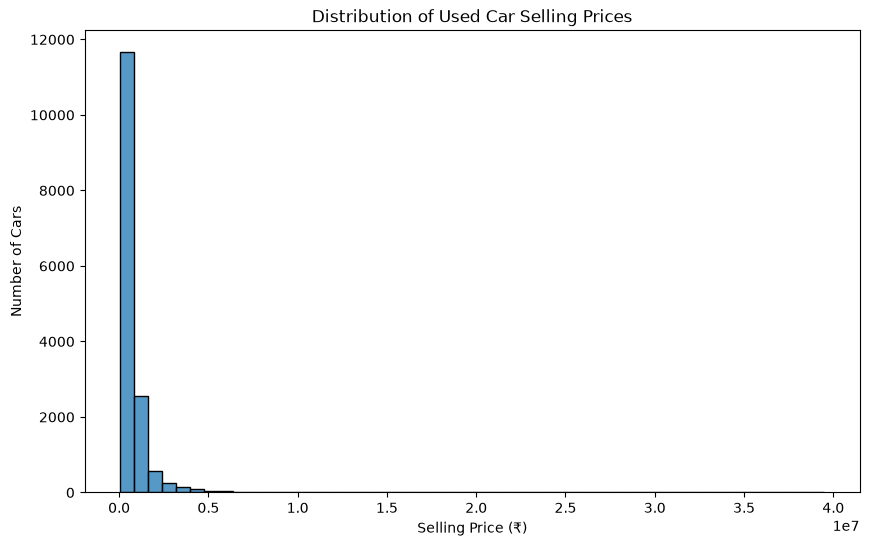

In [11]:
plt.figure(figsize=(10, 6))

sns.histplot(df["selling_price"], bins=50)

plt.title("Distribution of Used Car Selling Prices")
plt.xlabel("Selling Price (₹)")
plt.ylabel("Number of Cars")

plt.show()

In [12]:
# Create a copy for data cleaning

df_clean = df.copy()

print("Original rows:", len(df))
print("Clean dataset rows:", len(df_clean))

Original rows: 15411
Clean dataset rows: 15411


In [13]:
# Check for potentially invalid numerical values

print("Vehicle age <= 0:", (df_clean["vehicle_age"] <= 0).sum())
print("Kilometers driven <= 0:", (df_clean["km_driven"] <= 0).sum())
print("Mileage <= 0:", (df_clean["mileage"] <= 0).sum())
print("Engine <= 0:", (df_clean["engine"] <= 0).sum())
print("Max power <= 0:", (df_clean["max_power"] <= 0).sum())
print("Seats <= 0:", (df_clean["seats"] <= 0).sum())
print("Selling price <= 0:", (df_clean["selling_price"] <= 0).sum())

Vehicle age <= 0: 5
Kilometers driven <= 0: 0
Mileage <= 0: 0
Engine <= 0: 0
Max power <= 0: 0
Seats <= 0: 2
Selling price <= 0: 0


In [14]:
# Check the distribution of number of seats

df_clean["seats"].value_counts().sort_index()

seats
0        2
2        7
4       77
5    12910
6      127
7     1922
8      311
9       55
Name: count, dtype: int64

In [15]:
# cars with zero seats

df_clean[df_clean["seats"] == 0][
    ["car_name", "brand", "model", "vehicle_age", "seats", "selling_price"]
]

,car_name,brand,model,vehicle_age,seats,selling_price
3217,Honda City,Honda,City,18,0,115000
12619,Nissan Kicks,Nissan,Kicks,2,0,1154000


In [ ]:
# cars with the highest recorded mileage

df_clean.sort_values(
    "km_driven",
    ascending=False
)[
    [
        "car_name",
        "brand",
        "model",
        "vehicle_age",
        "km_driven",
        "selling_price"
    ]
].head(20)

,car_name,brand,model,vehicle_age,km_driven,selling_price
15409,Mahindra XUV500,Mahindra,XUV500,5,3800000,1225000
11903,Mercedes-Benz E-Class,Mercedes-Benz,E-Class,9,1325000,1350000
8772,Toyota Innova,Toyota,Innova,6,950000,950000
4532,Renault Duster,Renault,Duster,4,850000,850000
6712,Volkswagen Vento,Volkswagen,Vento,9,830000,380000
10838,Hyundai Creta,Hyundai,Creta,6,825000,825000
11615,Volkswagen Polo,Volkswagen,Polo,5,820000,695000
7323,Ford Ecosport,Ford,Ecosport,6,720000,675000
9170,Skoda Rapid,Skoda,Rapid,5,675000,675000
7534,Toyota Fortuner,Toyota,Fortuner,2,590000,2850000
